In [39]:
import matplotlib.pyplot as plt
# 1. Update global parameters for presentation visibility
plt.rcParams.update({
    'font.size': 18,              # General font size for text
    'axes.labelsize': 20,         # Size of X and Y axis labels
    'axes.titlesize': 24,         # Size of the graph title
    'xtick.labelsize': 16,        # Size of the numbers on the X axis
    'ytick.labelsize': 16,        # Size of the numbers on the Y axis
    'legend.fontsize': 16,        # Size of the legend text
    'lines.linewidth': 3,       # Thicker lines for the plotted data
})

In [40]:
import numpy as np

def calculate_relative_humidity(p, T, q):
    """
    Calculates the mixed water/ice relative humidity.
    
    Parameters:
    -----------
    p : array_like
        Atmospheric pressure in Pascals (Pa).
    T : array_like
        Temperature in Kelvin (K).
    q : array_like
        Specific humidity in kg/kg.
        
    Returns:
    --------
    rh : ndarray
        Relative humidity in percent (%).
    """
    # Convert inputs to numpy arrays
    p = np.asarray(p)
    T = np.asarray(T)
    q = np.asarray(q)
    
    # Constants
    epsilon = 0.621981
    T_0 = 273.16    # K
    T_ice = 250.16  # K
    
    # Tetens formula parameters for water (Buck 1981)
    a1_w = 611.21   # Pa
    a3_w = 17.502
    a4_w = 32.19    # K
    
    # Tetens formula parameters for ice (Alduchov and Eskridge 1996)
    a1_i = 611.21   # Pa
    a3_i = 22.587
    a4_i = -0.7     # K

    # 1. Calculate the mixed-phase parameter (alpha) [Eq. 7.94]
    alpha = np.zeros_like(T)
    
    # T >= T_0 (Liquid water phase)
    alpha[T >= T_0] = 1.0
    
    # T_ice < T < T_0 (Mixed phase)
    mask_mixed = (T > T_ice) & (T < T_0)
    alpha[mask_mixed] = ((T[mask_mixed] - T_ice) / (T_0 - T_ice)) ** 2
    
    # T <= T_ice (Ice phase, remains 0.0 as initialized)
    
    # 2. Calculate saturation partial pressure with respect to water and ice [Eq. 7.93]
    e_sat_w = a1_w * np.exp(a3_w * ((T - T_0) / (T - a4_w)))
    e_sat_i = a1_i * np.exp(a3_i * ((T - T_0) / (T - a4_i)))
    
    # 3. Calculate total saturation vapour pressure [Eq. 7.92]
    e_sat = alpha * e_sat_w + (1 - alpha) * e_sat_i
    
    # 4. Calculate partial pressure of water vapour (e)
    # Extracted from the numerator/denominator of Eq. 7.91
    e = (p * q / epsilon) / (1 + q * ((1 / epsilon) - 1))
    
    # 5. Calculate Relative Humidity (%) [Eq. 7.91]
    rh = 100.0 * (e / e_sat)
    
    return rh

In [42]:
#first, we import a profile
from scipy import constants
import xarray as xr
import pandas as pd
dataset = xr.open_dataset("/pscratch/sd/v/valer/icetmosphere/era5_profiles/dataset_2024-09_19-21-23.nc")

# SO site location
target_lon = -67.78
target_lat = -22.95

data_sep23 = dataset.interp(longitude=target_lon, latitude=target_lat, method="linear")
data_sep23 = data_sep23.sel(valid_time="2024-09-23T07:00:00")

site_altitude = 5100  # altitude of the site in meters
# Compute altitude from geopotential (z / g)
g = constants.g  # acceleration due to gravity from scipy.constants
altitude23 = data_sep23['z'].values / g  # altitude in meters for Sep 23

wvmr23 = data_sep23['q'].values #kg/kg
t23 = data_sep23['t'].values #K
cc23 = data_sep23['cc'].values #cloud cover ratio
ciwc23 = data_sep23['ciwc'].values #kg/kg
rh23 = data_sep23['r'].values #relative humidity in %
p23 = data_sep23['pressure_level'].values #hPa

# Ratio of the molecular weight of water vapor to dry air
epsilon = 0.62198

# Calculate vapor pressure
p_w23 = (wvmr23 * p23) / (epsilon + wvmr23)  # Vapor pressure in hPa

In [43]:
rh_calculated23 = calculate_relative_humidity(p23 * 100, t23, wvmr23)  # Convert pressure to Pa for the function

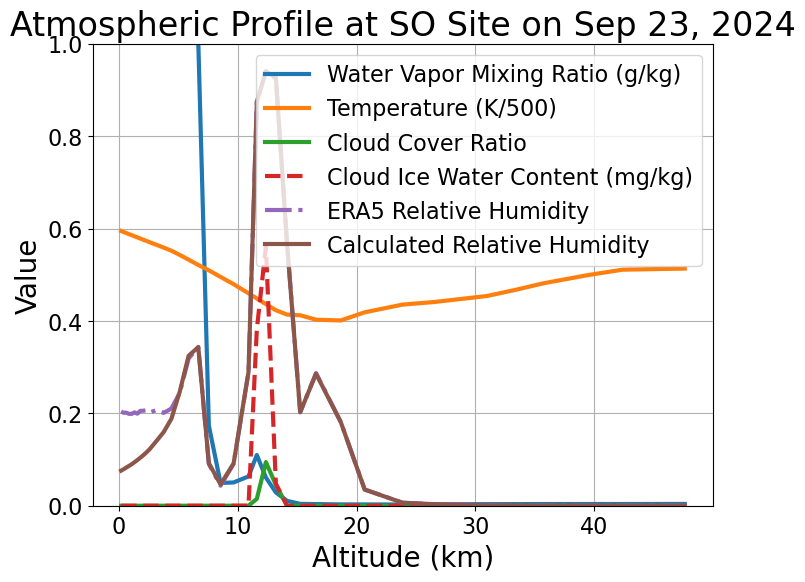

In [44]:
plt.figure(figsize=(8, 6))
plt.plot(altitude23/1000, wvmr23*1000, label='Water Vapor Mixing Ratio (g/kg)')
plt.plot(altitude23/1000, t23/500, label='Temperature (K/500)')
plt.plot(altitude23/1000, cc23, label='Cloud Cover Ratio')
plt.plot(altitude23/1000, ciwc23*1e6, label='Cloud Ice Water Content (mg/kg)', linestyle='--')
plt.plot(altitude23/1000, rh23/100, label='ERA5 Relative Humidity', linestyle='-.')
plt.plot(altitude23/1000, rh_calculated23/100, label='Calculated Relative Humidity ')
plt.ylim(0,1)
plt.xlabel('Altitude (km)')
plt.ylabel('Value')
plt.title('Atmospheric Profile at SO Site on Sep 23, 2024')
plt.legend()
plt.grid()
plt.show()

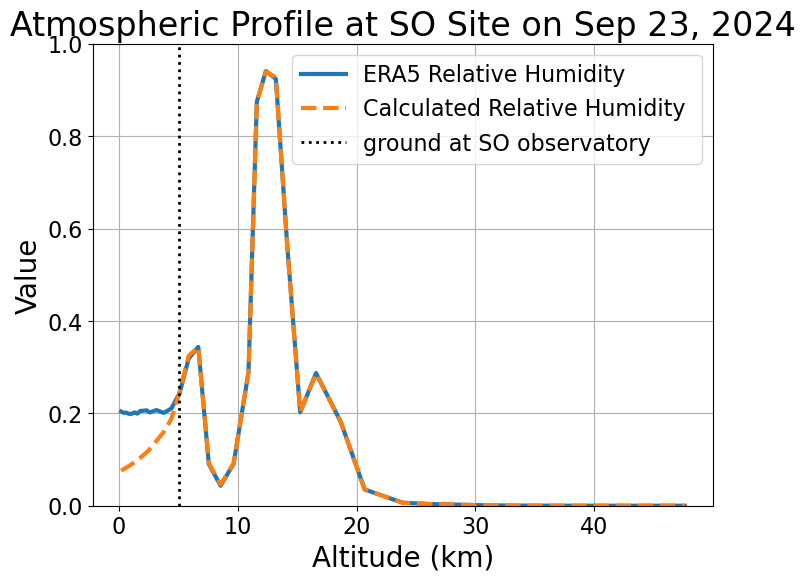

In [45]:
plt.figure(figsize=(8, 6))
plt.plot(altitude23/1000, rh23/100, label='ERA5 Relative Humidity')
plt.plot(altitude23/1000, rh_calculated23/100, label='Calculated Relative Humidity ', linestyle = '--')
plt.axvline(x=5.1, linestyle =':', color ='black', linewidth = 2, label = 'ground at SO observatory' )
plt.ylim(0,1)
plt.xlabel('Altitude (km)')
plt.ylabel('Value')
plt.title('Atmospheric Profile at SO Site on Sep 23, 2024')
plt.legend()
plt.grid()
plt.show()

In [52]:
import numpy as np
from scipy.ndimage import gaussian_filter1d, uniform_filter1d

# --- 1. Your Interpolation Setup ---
dz = 10 # vertical resolution in meters
L_era5 = altitude23[-1] - altitude23[0]
N_grid_era5 = int(L_era5 / dz)

altitude = np.linspace(altitude23.min(), altitude23.max(), N_grid_era5)

wvmr = np.interp(altitude, altitude23, wvmr23)
t    = np.interp(altitude, altitude23, t23)
cc   = np.interp(altitude, altitude23, cc23)
ciwc = np.interp(altitude, altitude23, ciwc23)
rh   = np.interp(altitude, altitude23, rh23)
p    = np.interp(altitude, altitude23, p23)

# --- 2. Defining the Free Parameter ---
# You can change this value to whatever you want (in meters)
injection_scale = 1000 # meters 

# --- 3. Grid Conversions ---
# Convert physical meters to array indices based on your dz
# Uniform filter requires an integer window size
window_size = int(np.round(injection_scale / dz)) 
sigma = window_size / np.sqrt(12)  # Convert window size to sigma for Gaussian filter

# --- 4. Applying the Filters ---
# Example on Water Vapor Mixing Ratio (wvmr)
wvmr_gaussian = gaussian_filter1d(wvmr, sigma=sigma)
wvmr_uniform = uniform_filter1d(wvmr, size=window_size)

# Example on Cloud Ice Water Content (ciwc)
ciwc_gaussian = gaussian_filter1d(ciwc, sigma=sigma)
ciwc_uniform = uniform_filter1d(ciwc, size=window_size)

# Example on Cloud Cover (cc) - clipping required to stay in bounds
cc_gaussian = np.clip(gaussian_filter1d(cc, sigma=sigma), 0.0, 1.0)
cc_uniform = np.clip(uniform_filter1d(cc, size=window_size), 0.0, 1.0)


#for temperature

t_uniform = uniform_filter1d(t, size=window_size)

p_uniform = uniform_filter1d(p, size=window_size)


In [47]:
print(window_size)

50


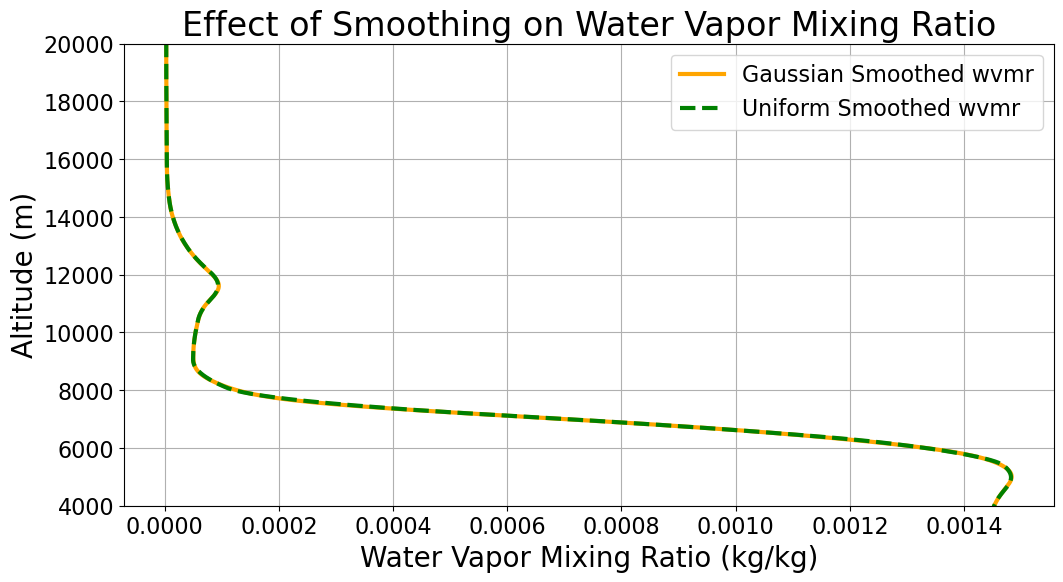

In [53]:
plt.figure(figsize=(12, 6))
#plt.plot(wvmr, altitude, label='Original wvmr', color='blue')
plt.plot(wvmr_gaussian, altitude, label='Gaussian Smoothed wvmr', color='orange')
plt.plot(wvmr_uniform, altitude, label='Uniform Smoothed wvmr', color='green', linestyle='--')
plt.xlabel('Water Vapor Mixing Ratio (kg/kg)')
plt.ylabel('Altitude (m)')
plt.title('Effect of Smoothing on Water Vapor Mixing Ratio')
plt.legend()
plt.grid()
plt.ylim(4000, 20000)
plt.show()

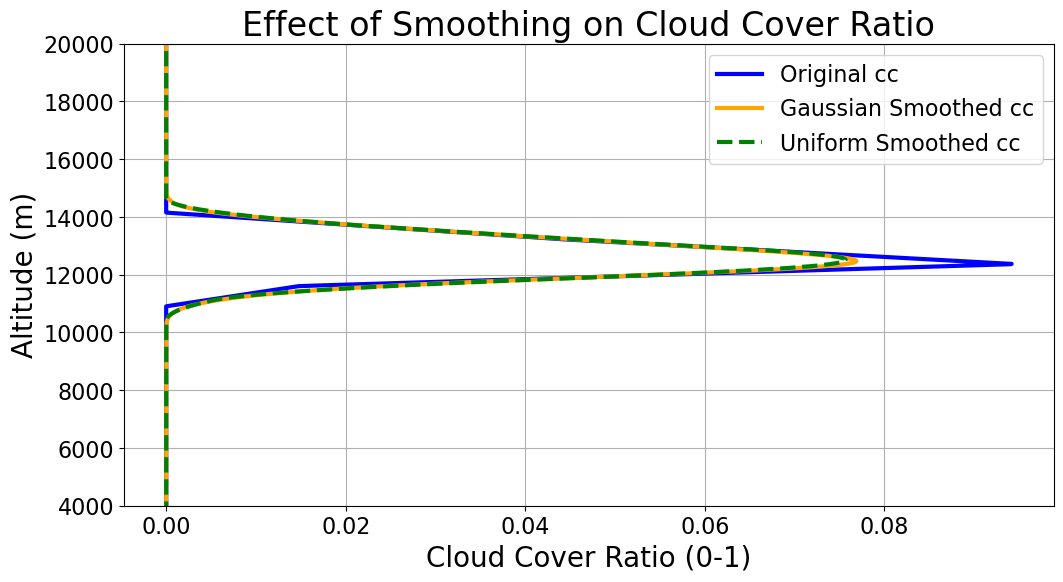

In [54]:
plt.figure(figsize=(12, 6))
plt.plot(cc, altitude, label='Original cc', color='blue')
plt.plot(cc_gaussian, altitude, label='Gaussian Smoothed cc', color='orange')
plt.plot(cc_uniform, altitude, label='Uniform Smoothed cc', color='green', linestyle='--')
plt.xlabel('Cloud Cover Ratio (0-1)')
plt.ylabel('Altitude (m)')
plt.title('Effect of Smoothing on Cloud Cover Ratio')
plt.legend()
plt.grid()
plt.ylim(4000, 20000)   
plt.show()

In [11]:

#altitude_mask = (altitude23 >= site_altitude) & (altitude23 <= 14500)

#altitude23_masked = altitude23[altitude_mask]

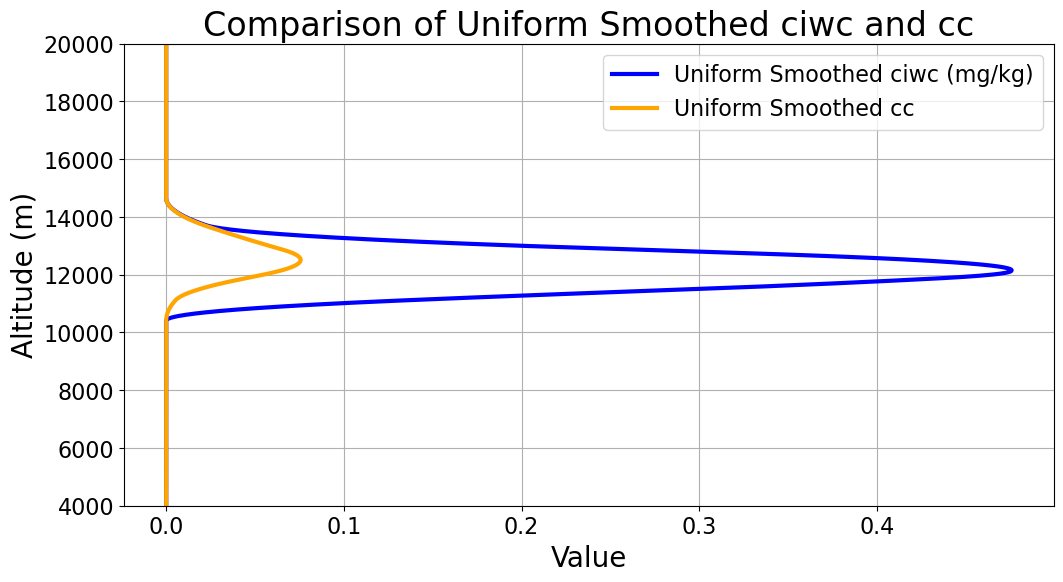

In [55]:
# we compare the filtered ciwc with the filtered cc

plt.figure(figsize=(12, 6))
plt.plot(ciwc_uniform*1e6, altitude, label='Uniform Smoothed ciwc (mg/kg)', color='blue')
plt.plot(cc_uniform, altitude, label='Uniform Smoothed cc', color='orange')
plt.xlabel('Value')
plt.ylabel('Altitude (m)')
plt.title('Comparison of Uniform Smoothed ciwc and cc')
plt.legend()
plt.grid()
plt.ylim(4000, 20000)
plt.show()

In [13]:
q_ice_uniform = np.divide(ciwc_uniform, cc_uniform, out=np.zeros_like(ciwc), where=(cc != 0))  # kg/kg, only where there are clouds

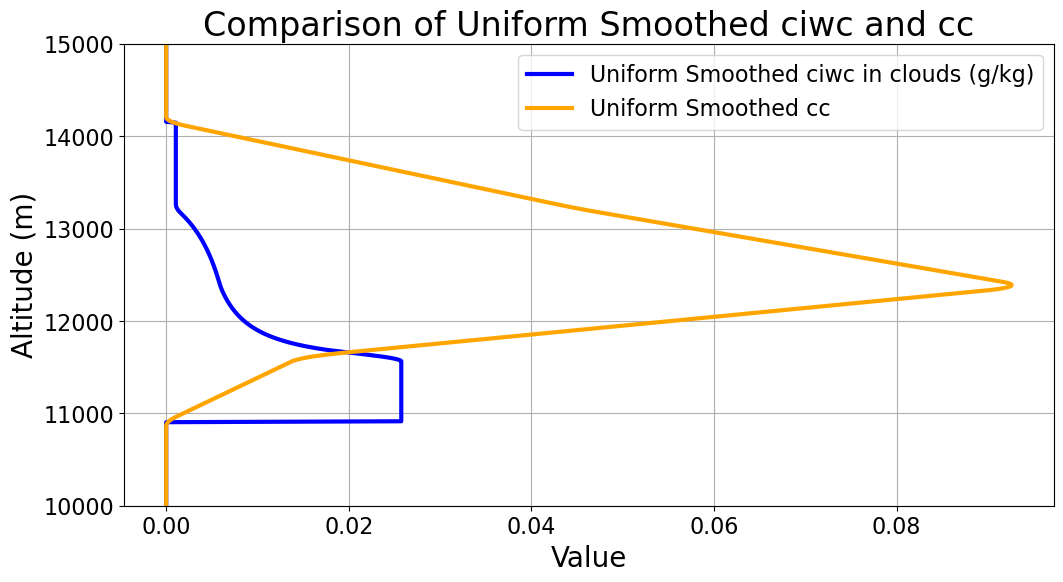

In [14]:
plt.figure(figsize=(12, 6))
plt.plot(q_ice_uniform*1e3, altitude, label='Uniform Smoothed ciwc in clouds (g/kg)', color='blue')
plt.plot(cc_uniform, altitude, label='Uniform Smoothed cc', color='orange')
plt.xlabel('Value')
plt.ylabel('Altitude (m)')
plt.title('Comparison of Uniform Smoothed ciwc and cc')
plt.legend()
plt.grid()
plt.ylim(10000, 15000)
plt.show()

In [35]:
import numpy as np

def calculate_q_ice_regularized(ciwc, cc, epsilon=0.01):
    """
    Calculates in-cloud ice water content using continuous regularization
    to avoid division by zero at cloud edges.
    
    Parameters:
    - ciwc: Grid-box cloud ice water content
    - cc: Cloud cover fraction (0.0 to 1.0)
    - epsilon: Damping factor (controls the smoothness at the edge)
    """
    # Calculate regularized q_ice
    q_ice = (ciwc * cc) / (cc**2 + epsilon**2)
    
    return q_ice

# Example using your ERA5 data
# An epsilon of 0.01 means clouds under 1% get heavily damped towards 0
q_ice_smooth = calculate_q_ice_regularized(ciwc_uniform, cc_uniform, epsilon=0.005)

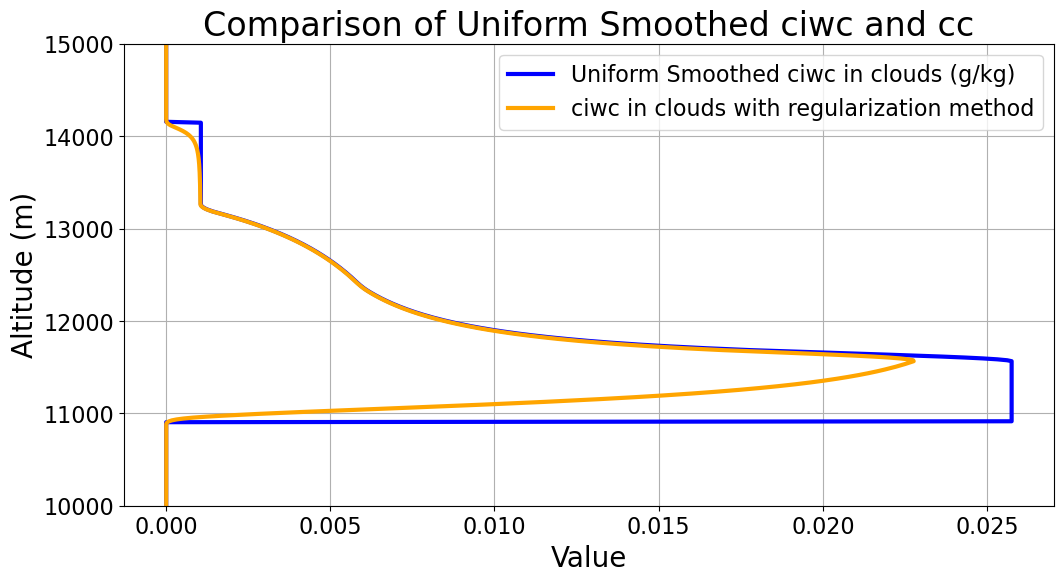

In [36]:
plt.figure(figsize=(12, 6))
plt.plot(q_ice_uniform*1e3, altitude, label='Uniform Smoothed ciwc in clouds (g/kg)', color='blue')
plt.plot(q_ice_smooth*1e3, altitude, label='ciwc in clouds with regularization method', color='orange')
plt.xlabel('Value')
plt.ylabel('Altitude (m)')
plt.title('Comparison of Uniform Smoothed ciwc and cc')
plt.legend()
plt.grid()
plt.ylim(10000, 15000)
plt.show()

In [24]:
#let's try another method, we'll consider that ciwc in clouds is the same everywhere

q_ice_clouds = np.zeros(len(q_ice_uniform))
mask = cc_uniform > 0.0001

q_ice_clouds [mask] = np.max(ciwc_uniform)/ np.max(cc_uniform)

In [22]:
print(cc_uniform)

[0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 2.94209102e-16
 2.94209102e-16 2.94209102e-16]


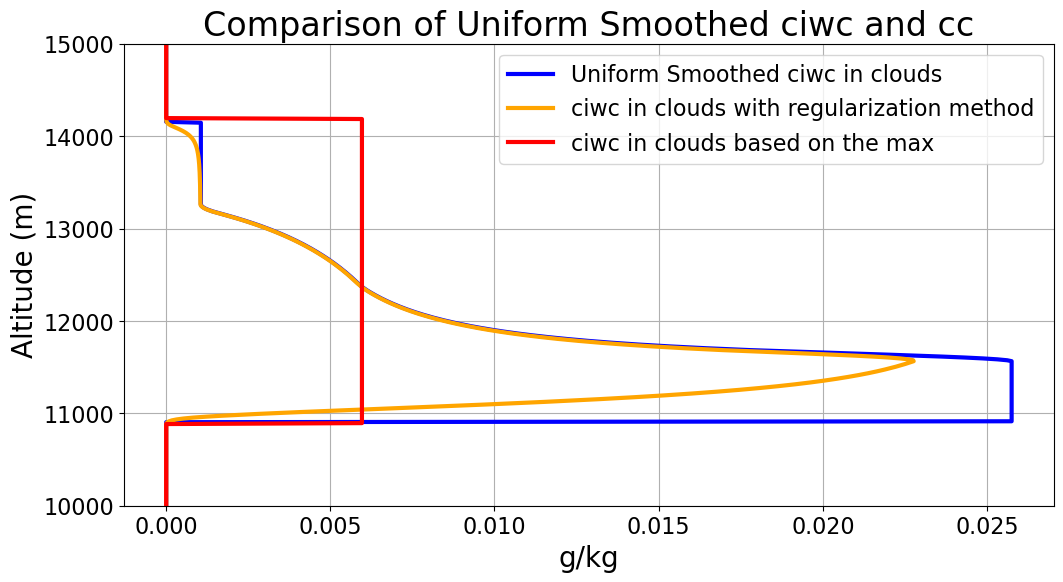

In [37]:
plt.figure(figsize=(12, 6))
plt.plot(q_ice_uniform*1e3, altitude, label='Uniform Smoothed ciwc in clouds ', color='blue')
plt.plot(q_ice_smooth*1e3, altitude, label='ciwc in clouds with regularization method', color='orange')
plt.plot(q_ice_clouds*1e3, altitude, label = 'ciwc in clouds based on the max', color ='red')
plt.xlabel('g/kg')
plt.ylabel('Altitude (m)')
plt.title('Comparison of Uniform Smoothed ciwc and cc')
plt.legend()
plt.grid()
plt.ylim(10000, 15000)
plt.show()

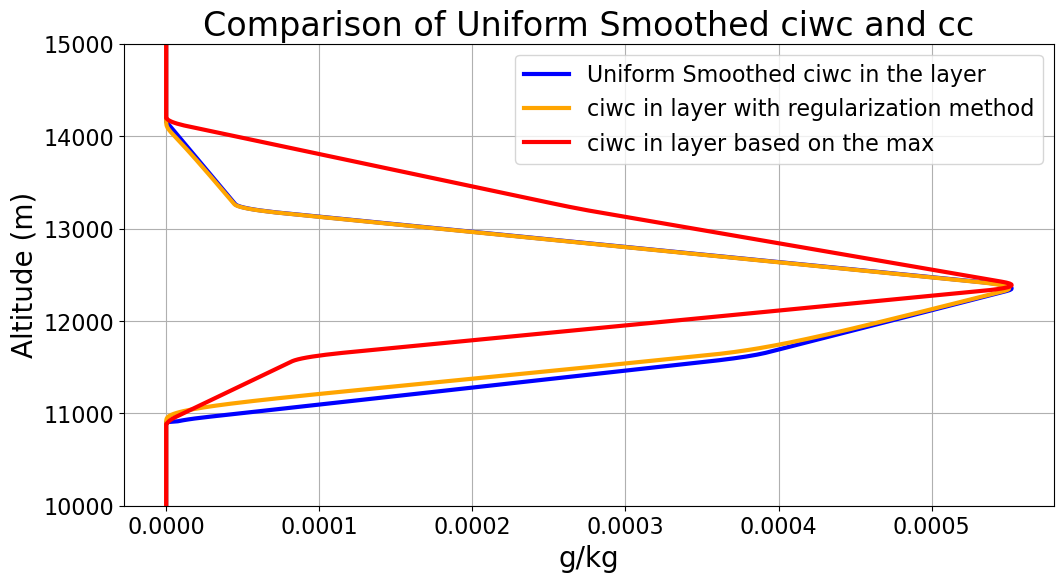

In [38]:
plt.figure(figsize=(12, 6))
plt.plot(q_ice_uniform*1e3*cc_uniform, altitude, label='Uniform Smoothed ciwc in the layer ', color='blue')
plt.plot(q_ice_smooth*1e3*cc_uniform, altitude, label='ciwc in layer with regularization method', color='orange')
plt.plot(q_ice_clouds*1e3*cc_uniform, altitude, label = 'ciwc in layer based on the max', color ='red')
plt.plot()
plt.xlabel('g/kg')
plt.ylabel('Altitude (m)')
plt.title('Comparison of Uniform Smoothed ciwc and cc')
plt.legend()
plt.grid()
plt.ylim(10000, 15000)
plt.show()